# Bài toán Logistic Regression theo góc nhìn Deep Learning

Trong Deep Learning, Logistic Regression là một mạng nơ-ron với 1 layer duy nhất. Quá trình dự đoán (Forward Propagation) được tính bằng công thức:
$$Z = w_1x_1 + w_2x_2 + b$$
$$\hat{y} = \sigma(Z) = \frac{1}{1 + e^{-Z}}$$

Trong đó:
* $x_1, x_2$ là các đặc trưng đầu vào (ví dụ: tọa độ 2D của một điểm).
* $w_1, w_2$ là trọng số (Weights) và $b$ là độ lệch (Bias).
* $\sigma(Z)$ là hàm Sigmoid, giúp nén giá trị $Z$ về khoảng $(0, 1)$.
* $\hat{y}$ là xác suất dự đoán điểm dữ liệu thuộc lớp $1$.

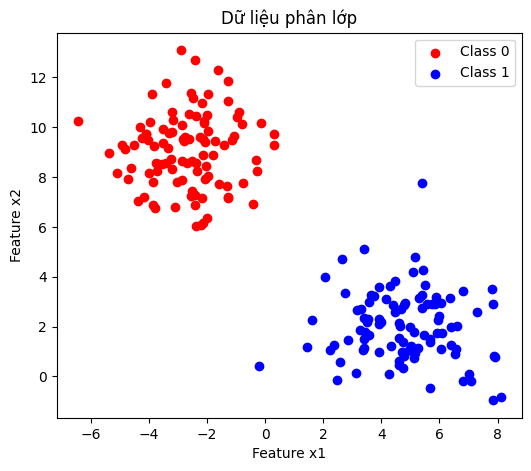

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Tạo dữ liệu giả lập gồm 2 cụm (2 class: 0 và 1)
np.random.seed(42)
X, y = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=1.5, random_state=42)

# Reshape y thành vector cột (N, 1) để chuẩn hóa tính toán ma trận
y = y.reshape(-1, 1)

# Vẽ dữ liệu ra xem thử
plt.figure(figsize=(6, 5))
plt.scatter(X[y[:, 0] == 0][:, 0], X[y[:, 0] == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y[:, 0] == 1][:, 0], X[y[:, 0] == 1][:, 1], color='blue', label='Class 1')
plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.title("Dữ liệu phân lớp")
plt.legend()
plt.show()

## Hàm mất mát (Binary Cross-Entropy) và Cập nhật trọng số

Trong phân lớp nhị phân, chúng ta không dùng MSE nữa mà dùng hàm **Binary Cross-Entropy (BCE) Loss**:
$$L = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

Toán học trong Deep Learning cực kỳ vi diệu ở chỗ, khi tính đạo hàm của hàm BCE này kết hợp với hàm Sigmoid, kết quả thu được lại vô cùng gọn gàng (Backpropagation):
* $\frac{\partial L}{\partial w} = \frac{1}{N} X^T (\hat{y} - y)$
* $\frac{\partial L}{\partial b} = \frac{1}{N} \sum (\hat{y} - y)$

Thuật toán Gradient Descent sẽ dùng đạo hàm này để trừ ngược lại vào $w$ và $b$, giúp mô hình thông minh dần lên.

In [2]:
# Khởi tạo tham số w (2 features) và b ngẫu nhiên
w = np.random.randn(2, 1)
b = np.random.randn(1)

# Hàm Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Các siêu tham số (Hyperparameters)
learning_rate = 0.1
epochs = 200
N = len(X)

# Lưu lại lịch sử loss
loss_history = []

# Vòng lặp huấn luyện (Training loop)
for epoch in range(epochs):
    # 1. Forward pass (Lan truyền tiến)
    Z = np.dot(X, w) + b
    y_hat = sigmoid(Z)

    # 2. Tính Binary Cross-Entropy Loss
    # Thêm 1e-8 để tránh lỗi log(0)
    loss = -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))
    loss_history.append(loss)

    # 3. Backward pass (Tính đạo hàm)
    dz = y_hat - y
    dw = (1/N) * np.dot(X.T, dz)
    db = (1/N) * np.sum(dz)

    # 4. Cập nhật trọng số (Gradient Descent)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # In kết quả sau mỗi 40 epochs
    if epoch % 40 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

print("\nHuấn luyện hoàn tất!")
print(f"Trọng số cuối cùng: w1={w[0][0]:.4f}, w2={w[1][0]:.4f}, b={b[0]:.4f}")

Epoch 0: Loss = 0.1210
Epoch 40: Loss = 0.0242
Epoch 80: Loss = 0.0165
Epoch 120: Loss = 0.0132
Epoch 160: Loss = 0.0113

Huấn luyện hoàn tất!
Trọng số cuối cùng: w1=1.3481, w2=-0.4577, b=0.8000


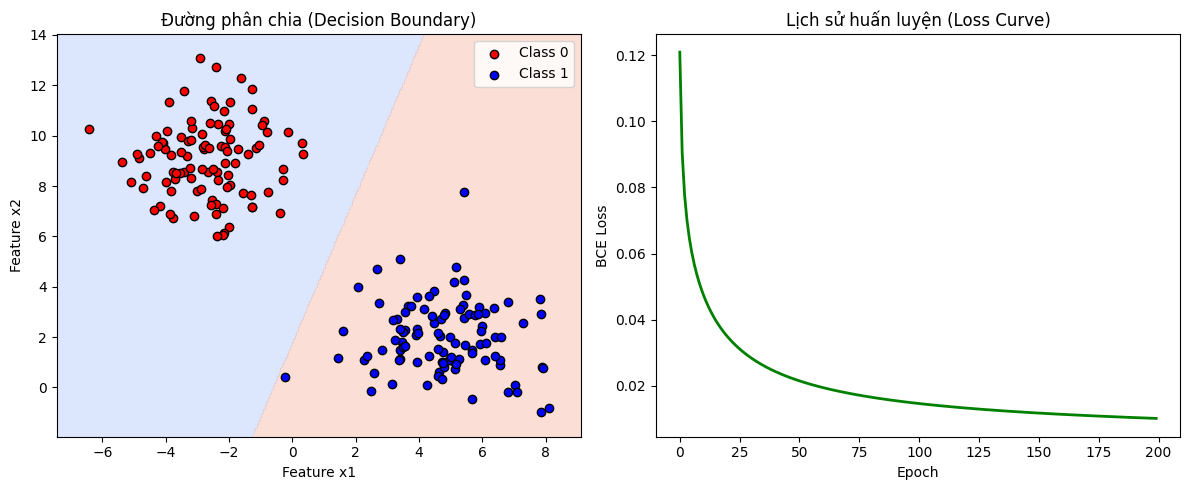

In [3]:
# Cài đặt vùng không gian để vẽ đường phân chia (Decision Boundary)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Dự đoán trên toàn bộ không gian
Z_grid = np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b
y_grid_pred = sigmoid(Z_grid)
y_grid_pred = y_grid_pred.reshape(xx.shape)

plt.figure(figsize=(12, 5))

# Đồ thị 1: Decision Boundary
plt.subplot(1, 2, 1)
# Vẽ vùng màu dự đoán (ngưỡng 0.5)
plt.contourf(xx, yy, y_grid_pred > 0.5, alpha=0.3, cmap='coolwarm')
plt.scatter(X[y[:, 0] == 0][:, 0], X[y[:, 0] == 0][:, 1], color='red', edgecolors='k', label='Class 0')
plt.scatter(X[y[:, 0] == 1][:, 0], X[y[:, 0] == 1][:, 1], color='blue', edgecolors='k', label='Class 1')
plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.title("Đường phân chia (Decision Boundary)")
plt.legend()

# Đồ thị 2: Quá trình giảm Loss
plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss_history, "g-", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Lịch sử huấn luyện (Loss Curve)")

plt.tight_layout()
plt.show()